In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

In [28]:
# Load CSV
date = "2025-02-05"
data_dir = Path(f"AQPX_data_log_{date}.csv")
base_dir = Path(r"D:\aqpx\Cabrera_Thesis_AQPX\Transfer_Function_Modeling\data_calibrated")
df = pd.read_csv(base_dir / data_dir)

# Clean Time column
df["Time"] = df["Time"].astype(str).str.strip()

# Combine date + time into a proper datetime
dtime = pd.to_datetime(
    date + " " + df["Time"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

In [29]:
do = df["MCP_WQ_DO"]
#downscale values
factor = 20
dtime_small = dtime[::factor]
do_small = do[::factor]

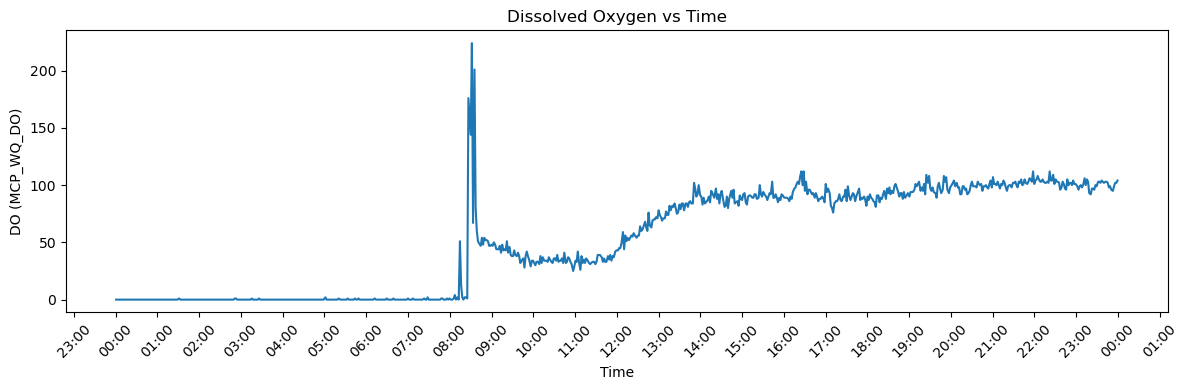

In [30]:
plt.figure(figsize=(12,4))
plt.plot(dtime_small, do_small)

plt.xlabel("Time")
plt.ylabel("DO (MCP_WQ_DO)")
plt.title("Dissolved Oxygen vs Time")

# HOURLY TICKS
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
